In [24]:

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import math, time, os, pickle
import matplotlib.pyplot as plt


class NALU2M(nn.Module):
    def __init__(self, in_features, out_features, dependent_g=True):
        super().__init__()
        self.W0_hat = nn.Parameter(torch.Tensor(in_features, out_features))
        self.M0_hat = nn.Parameter(torch.Tensor(in_features, out_features))
        self.W1_hat = nn.Parameter(torch.Tensor(in_features, out_features))
        self.M1_hat = nn.Parameter(torch.Tensor(in_features, out_features))
        self.dependent_g = dependent_g
        self.G = nn.Parameter(torch.Tensor(in_features, out_features) if dependent_g else torch.Tensor(out_features))
        self.eps = 1e-10
        self.reset_parameters()

    def reset_parameters(self):
        for p in [self.W0_hat, self.M0_hat, self.W1_hat, self.M1_hat, self.G]:
            nn.init.uniform_(p, -1e-2, 1e-2)

    def forward(self, x):
        W0 = torch.tanh(self.W0_hat) * torch.sigmoid(self.M0_hat)  
        W1 = torch.tanh(self.W1_hat) * torch.sigmoid(self.M1_hat)

        a = torch.matmul(x, W0)  
        log_x = torch.log(torch.clamp(torch.abs(x), min=self.eps))
        m = torch.exp(torch.matmul(log_x, W1))

        if self.dependent_g:
            g = torch.sigmoid(torch.matmul(x, self.G))
        else:
            g = torch.sigmoid(self.G)
        
        g = torch.clamp(torch.sigmoid(torch.matmul(x, self.G)), 0.01, 0.99)


        return g * a + (1 - g) * m

class NALUIG(nn.Module):
    def __init__(self, in_features, out_features):
        super().__init__()
        self.W0_hat = nn.Parameter(torch.Tensor(in_features, out_features))  
        self.M0_hat = nn.Parameter(torch.Tensor(in_features, out_features))
        self.G = nn.Parameter(torch.Tensor(out_features))  
        self.eps = 1e-10
        self.reset_parameters()

    def reset_parameters(self):
        nn.init.uniform_(self.W0_hat, -1e-2, 1e-2)
        nn.init.uniform_(self.M0_hat, -1e-2, 1e-2)
        nn.init.uniform_(self.G, -1e-2, 1e-2)

    def forward(self, x):
        W0 = torch.tanh(self.W0_hat) * torch.sigmoid(self.M0_hat)  
        a = torch.matmul(x, W0)
        m = torch.exp(torch.matmul(torch.log(torch.abs(x) + self.eps), W0))

        g = torch.sigmoid(self.G)
        if g.dim() == 1:
          g = g.unsqueeze(0)  
        return g * a + (1 - g) * m

class NALU2MIG(nn.Module):
    def __init__(self, in_features, out_features):
        super().__init__()
        self.W0_hat = nn.Parameter(torch.Tensor(in_features, out_features))
        self.M0_hat = nn.Parameter(torch.Tensor(in_features, out_features))
        self.W1_hat = nn.Parameter(torch.Tensor(in_features, out_features))
        self.M1_hat = nn.Parameter(torch.Tensor(in_features, out_features))
        self.G = nn.Parameter(torch.Tensor(out_features))  
        self.eps = 1e-10
        self.reset_parameters()

    def reset_parameters(self):
        for p in [self.W0_hat, self.M0_hat, self.W1_hat, self.M1_hat, self.G]:
            nn.init.uniform_(p, -1, 1)

    def forward(self, x):
        W0 = torch.tanh(self.W0_hat) * torch.sigmoid(self.M0_hat)
        W1 = torch.tanh(self.W1_hat) * torch.sigmoid(self.M1_hat)
        a = torch.matmul(x, W0)
        m = torch.exp(torch.matmul(torch.log(torch.abs(x) + self.eps), W1))
        g = torch.sigmoid(self.G)
        if g.dim() == 1:
            g = g.unsqueeze(0)
        return g * a + (1 - g) * m

class NALU2MIG_improved(nn.Module):
    def __init__(self, in_features, out_features):
        super().__init__()
        self.W0_hat = nn.Parameter(torch.Tensor(in_features, out_features))
        self.M0_hat = nn.Parameter(torch.Tensor(in_features, out_features))
        self.W1_hat = nn.Parameter(torch.Tensor(in_features, out_features))
        self.M1_hat = nn.Parameter(torch.Tensor(in_features, out_features))
        self.G = nn.Parameter(torch.Tensor(out_features))  
        self.eps = 1e-10
        self.reset_parameters()

    def reset_parameters(self):
        for p in [self.W0_hat, self.M0_hat, self.W1_hat, self.M1_hat, self.G]:
            nn.init.uniform_(p, -1, 1)

    def forward(self, x):
        W0 = torch.tanh(self.W0_hat) * torch.sigmoid(self.M0_hat)
        W1 = torch.tanh(self.W1_hat) * torch.sigmoid(self.M1_hat)

        a = torch.matmul(x, W0)
        x_safe = F.softplus(x) + self.eps
        m = torch.exp(torch.matmul(torch.log1p(x_safe), W1))

        g = torch.sigmoid(self.G)
        if g.dim() == 1:
            g = g.unsqueeze(0)
        return g * a + (1 - g) * m

class FactorizedNALU(nn.Module):
    def __init__(self, in_features, out_features, rank=10):
        super().__init__()
        self.Ua = nn.Linear(in_features, rank, bias=False)
        self.Va = nn.Linear(rank, out_features, bias=False)
        self.Um = nn.Linear(in_features, rank, bias=False)
        self.Vm = nn.Linear(rank, out_features, bias=False)
        self.G = nn.Parameter(torch.Tensor(out_features))
        self.eps = 1e-7
        self.reset_parameters()

    def reset_parameters(self):
        nn.init.uniform_(self.G, -1e-2, 1e-2)
        for layer in [self.Ua, self.Va, self.Um, self.Vm]:
            nn.init.uniform_(layer.weight, -1e-2, 1e-2)
            if layer.bias is not None:
                nn.init.zeros_(layer.bias)

    def forward(self, x):
        g = torch.sigmoid(self.G).unsqueeze(0)
        a = self.Va(self.Ua(x))
        log_x = torch.log1p(F.softplus(x))  
        m = torch.exp(self.Vm(self.Um(log_x)))
        return g * a + (1 - g) * m



In [25]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import math, time, os, pickle
import matplotlib.pyplot as plt
import time


functions = {
    'a + b':   lambda a, b: a + b,
    'a - b':   lambda a, b: a - b,
    'a x b':   lambda a, b: a * b,
    'a ^ 2':   lambda a, b: a**2,
}

activations = {
    'ReLU':    nn.ReLU(),
    'Sigmoid': nn.Sigmoid(),
}

IN_DIM = 100
HIDDEN_DIM = 8
N, M = 0, 10
P, Q = 70, 100


best_models = {}

def load_data(op, scale, train_size, test_size):
    
    np.random.seed(0)
    func = functions[op]
    x_train = np.random.uniform(0, scale, size=(train_size, IN_DIM))
    x_train /= scale
    y_train = func(np.sum(x_train[:, N:M], axis=1), np.sum(x_train[:, P:Q], axis=1))


    a_max = np.max(np.sum(x_train[:, N:M], axis=1))
    b_max = np.max(np.sum(x_train[:, P:Q], axis=1))        
    
    y_max = np.max(np.abs(y_train))
    if y_max <= 0:
        raise ValueError(f"Invalid y_max={y_max:.4f}. Cannot normalize by non-positive value.")
    y_train = y_train / y_max
    def sample_test(scale_factor, condition, max_samples):
        x_list, y_list, count = [], [], 0
        t1 = time.time()
        max_attempts = 1000
        attempts = 0
        while count < max_samples and attempts < max_attempts:
            
            x = np.random.uniform(0, scale * scale_factor, size=(max_samples, IN_DIM))
            x = (x - x.mean(axis=0)) / x.std(axis=0)
            a = np.sum(x[:, N:M], axis=1)
            b = np.sum(x[:, P:Q], axis=1)
                
            y = func(a, b)
            y = y/y_max
            mask = condition(a, b, y)
            x_list.append(x[mask])
            y_list.append(y[mask])
            count += np.sum(mask)
            attempts += 1
        if count < max_samples:
            print(f"[Warning] Only collected {count} samples after {max_attempts} attempts")
        return np.concatenate(x_list)[:max_samples], np.concatenate(y_list)[:max_samples]

    
    in_cond = lambda a, b, y: (a < a_max) & (b < b_max) & (y < y_max)
    out_cond = lambda a, b, y: (a >= a_max) | (b >= b_max) | (y >= y_max)

    x_test_i, y_test_i = sample_test(1, in_cond, test_size)
    
    x_test_e, y_test_e = sample_test(4, out_cond, test_size)
    

    return (x_train.astype(np.float32), y_train.astype(np.float32),
            x_test_i.astype(np.float32), y_test_i.astype(np.float32),
            x_test_e.astype(np.float32), y_test_e.astype(np.float32))



def evaluate_rmse(net, loader, device):
    net.eval()
    loss_fn = nn.MSELoss(reduction='sum')
    total_loss, total_count = 0, 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            pred = net(x)
            loss = loss_fn(pred, y.view(-1, 1))
            total_loss += loss.item()
            total_count += y.size(0)
    return math.sqrt(total_loss / total_count)

def calculate_errors(y_true, y_pred):
    mae = np.mean(np.abs(y_true - y_pred))
    mse = np.mean((y_true - y_pred) ** 2)
    rmse = np.sqrt(mse)
    mad = np.mean(np.abs(y_true - np.mean(y_true)))
    return mae, mse, rmse, mad

def calculate_accuracy(y_true, y_pred, threshold=0.1):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    denominator = np.maximum(np.abs(y_true), 1e-8)
    relative_error = np.abs(y_true - y_pred) / denominator
    return np.mean(relative_error < threshold)

def get_random_baseline(x_test_i, y_test_i, x_test_e, y_test_e, n_repeat=20):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    batch_size = 1024

    x_test_i = torch.tensor(x_test_i, dtype=torch.float32)
    y_test_i = torch.tensor(y_test_i, dtype=torch.float32)
    x_test_e = torch.tensor(x_test_e, dtype=torch.float32)
    y_test_e = torch.tensor(y_test_e, dtype=torch.float32)

    loader_i = DataLoader(TensorDataset(x_test_i, y_test_i), batch_size=batch_size)
    loader_e = DataLoader(TensorDataset(x_test_e, y_test_e), batch_size=batch_size)
    total_rmse_i, total_rmse_e = 0, 0
    
    for _ in range(n_repeat):
        net = nn.Sequential(
            nn.Linear(IN_DIM, HIDDEN_DIM),
            nn.Linear(HIDDEN_DIM, 1)
        )
        for layer in net:
            if isinstance(layer, nn.Linear):
                nn.init.uniform_(layer.weight, -1.0, 1.0)
                if layer.bias is not None:
                    nn.init.uniform_(layer.bias, -1.0, 1.0)

        net.to(device)

        rmse_i = evaluate_rmse(net, loader_i, device)
        rmse_e = evaluate_rmse(net, loader_e, device)

        total_rmse_i += rmse_i
        total_rmse_e += rmse_e

    avg_rmse_i = total_rmse_i / n_repeat
    avg_rmse_e = total_rmse_e / n_repeat

    return avg_rmse_i, avg_rmse_e



In [ ]:

def log_weight_stats(net, tag=""):
    for name, param in net.named_parameters():
        if param.requires_grad:
            max_val = param.data.abs().max().item()
            mean_val = param.data.abs().mean().item()
            print(f"[{tag}] Param: {name:20} | Max: {max_val:8.4f} | Mean: {mean_val:8.4f}")



def train_static(op, net_type, net, x_train, y_train, x_test_i, y_test_i, x_test_e, y_test_e,
                 random_i, random_e, params):
    import time
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    net.to(device)
    batch_size = params['batch_size']

    train_data = DataLoader(TensorDataset(
        torch.tensor(x_train),
        torch.tensor(y_train).view(-1, 1)
    ), batch_size=batch_size, shuffle=True)

    test_i_data = DataLoader(TensorDataset(
        torch.tensor(x_test_i),
        torch.tensor(y_test_i).view(-1, 1)
    ), batch_size=batch_size * 10)

    test_e_data = DataLoader(TensorDataset(
        torch.tensor(x_test_e),
        torch.tensor(y_test_e).view(-1, 1)
    ), batch_size=batch_size * 10)

    optimizer = optim.Adam(net.parameters(), **params['optimizer_params'])
    l2loss = nn.MSELoss()
    print_every = 5
    best_loss = float('inf')
    moving_loss = None

    start_time_i = time.time()
    i_rmse = evaluate_rmse(net, test_i_data, device)
    training_time_i = time.time() - start_time_i

    start_time_e = time.time()
    e_rmse = evaluate_rmse(net, test_e_data, device)
    training_time_e = time.time() - start_time_e

    
    print("[Experiment] Initial interpolation and extrapolation results (Relative RMSE vs. random baseline (% of baseline)")
    print(f"[Init] I-RMSE: {i_rmse:.4f} ({i_rmse / random_i * 100:.1f}%) | E-RMSE: {e_rmse:.4f} ({e_rmse / random_e * 100:.1f}%) | ")

    training_start = time.time()
    epochs_list = []
    i_rmse_list = []
    e_rmse_list = []
    loss_list = []

    for epoch in range(params['n_epoch']):
        net.train()
        for i, (data, label) in enumerate(train_data):
            data, label = data.to(device), label.to(device)
            optimizer.zero_grad()
            output = net(data)
            loss = l2loss(output, label)
            loss.backward()
            optimizer.step()


            loss_val = loss.item()
            moving_loss = loss_val if moving_loss is None else 0.99 * moving_loss + 0.01 * loss_val

        if (epoch) % print_every == 0:
            net.eval()
            i_rmse = evaluate_rmse(net, test_i_data, device)
            e_rmse = evaluate_rmse(net, test_e_data, device)
            start_time_i = time.time()
            i_rmse = evaluate_rmse(net, test_i_data, device)
            training_time_i += time.time() - start_time_i

            start_time_e = time.time()
            e_rmse = evaluate_rmse(net, test_e_data, device)
            training_time_e += time.time() - start_time_e
            print(f"Epoch {epoch:03d} | I-RMSE: {i_rmse:.4f} ({i_rmse / random_i * 100:.1f}%) | E-RMSE: {e_rmse:.4f} ({e_rmse / random_e * 100:.1f}%) | Loss: {moving_loss:.6f}")
            epochs_list.append(epoch)
            i_rmse_list.append(i_rmse)
            e_rmse_list.append(e_rmse)
            loss_list.append(moving_loss)

            if i_rmse + e_rmse < best_loss:
                best_loss = i_rmse + e_rmse
                best_models[(op, net_type)] = net.state_dict()
                op_name = ''
                if(op=='a + b'):
                    op_name = 'addition'
                if(op=='a - b'):
                    op_name = 'subtraction'
                if(op=='a x b'):
                    op_name = 'multiplication'
                if(op=='a ^ 2'):
                    op_name = 'power'
                
                torch.save(net.state_dict(), f"{op_name}_{net_type}_best.pt")

    net.eval()
    with torch.no_grad():
        y_pred_i = net(torch.tensor(x_test_i, dtype=torch.float32, device=device)).cpu().numpy()
        y_pred_e = net(torch.tensor(x_test_e, dtype=torch.float32, device=device)).cpu().numpy()

    metrics = {
        'i_rmse_list': i_rmse_list,
        'e_rmse_list': e_rmse_list,
        'loss_list': loss_list,
        'epochs_list': epochs_list,
        'i_mae': None,
        'i_mse': None,
        'i_rmse': None,
        'i_mad': None,
        'e_mae': None,
        'e_mse': None,
        'e_rmse': None,
        'e_mad': None,
        'accuracy_i': calculate_accuracy(y_test_i, y_pred_i),
        'accuracy_e': calculate_accuracy(y_test_e, y_pred_e),
        'training_time_i': training_time_i,
        'training_time_e': training_time_e
    }

    metrics['i_mae'], metrics['i_mse'], metrics['i_rmse'], metrics['i_mad'] = calculate_errors(y_test_i, y_pred_i)
    metrics['e_mae'], metrics['e_mse'], metrics['e_rmse'], metrics['e_mad'] = calculate_errors(y_test_e, y_pred_e)
    
    return metrics

def visualize_data(x_train, y_train, x_test_i, y_test_i, x_test_e, y_test_e, op):
    import matplotlib.pyplot as plt

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    axes[0].scatter(x_train[:, 0], y_train, s=10, alpha=0.5)
    axes[0].set_title(f"{op} - Training Data")
    axes[1].scatter(x_test_i[:, 0], y_test_i, s=10, alpha=0.5)
    axes[1].set_title(f"{op} - Interpolation Test")
    axes[2].scatter(x_test_e[:, 0], y_test_e, s=10, alpha=0.5)
    axes[2].set_title(f"{op} - Extrapolation Test")

    for ax in axes:
        ax.set_xlabel("Input Feature(s)")
        ax.set_ylabel("Target Output")
        ax.grid(True)

    plt.suptitle(f"Input vs Target for {op}")
    plt.tight_layout()
    plt.show()

def plot_input_histogram(x, op):
    import matplotlib.pyplot as plt

    plt.figure(figsize=(8, 4))
    plt.hist(x.flatten(), bins=100, alpha=0.7)
    plt.title(f"Input Value Histogram - {op}")
    plt.xlabel("Input Value")
    plt.ylabel("Frequency")
    plt.grid(True)
    plt.show()
def plot_training_curves(training_info, op, curve_type):
    SMALL_SIZE = 8
    MEDIUM_SIZE = 10
    plt.rc('font', size=SMALL_SIZE)
    plt.rc('axes', titlesize=MEDIUM_SIZE)
    plt.rc('axes', labelsize=MEDIUM_SIZE)
    plt.rc('xtick', labelsize=SMALL_SIZE)
    plt.rc('ytick', labelsize=SMALL_SIZE)
    plt.rc('legend', fontsize=SMALL_SIZE)

    def make_plot(title_suffix,op, include_nalu2mig=True ):
        plt.figure(figsize=(4, 3))  
        for (key_op, net_type), info in training_info.items():
            if key_op != op:
                continue
            if include_nalu2mig and net_type not in ['NALU2MIG', 'NALU2MIG_improved']:
                continue
            if not include_nalu2mig and net_type == 'NALU2MIG':
                continue

            if curve_type == 'i_rmse':
                plt.plot(info['epochs'], info['i_rmse'], label=net_type)
            elif curve_type == 'e_rmse':
                plt.plot(info['epochs'], info['e_rmse'], label=net_type)
            elif curve_type == 'loss':
                plt.plot(info['epochs'], info['loss'], label=net_type)

        plt.xlabel("Epoch")
        plt.ylabel("Value")
        plt.title(f"{op}: {curve_type.upper()} {title_suffix}", fontsize=MEDIUM_SIZE)
        plt.grid(True, linestyle='--', alpha=0.5)
        plt.legend(loc='best', frameon=False)
        plt.tight_layout()
        plt.show()

    make_plot("- NALU2MIG",op, include_nalu2mig=True, )
    make_plot("",op, include_nalu2mig=False )


def plot_param_histogram(param_counts, op_filter=None):
    entries = [(net_type, count) for (op, net_type), count in param_counts.items() if op_filter is None or op == op_filter]

    if not entries:
        print(f"No parameter counts found for op='{op_filter}'")
        return

    labels, counts = zip(*entries)
    plt.figure(figsize=(12, 6))
    plt.bar(labels, counts)
    plt.xticks(rotation=45, ha='right')
    plt.ylabel("Number of Trainable Parameters")
    plt.title(f"Model Parameter Counts{' for ' + op_filter if op_filter else ''}")
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def plot_results(results):
    for task in results.keys():
        mae = []
        rmse = []
        acc = []
        labels = []
        data = {}

        if task == "interpolation":
            title = "Interpolation Results"
            data = results["interpolation"]
        elif task == "extrapolation":
            title = "Extrapolation Results"
            data = results["extrapolation"]

        for (op, net_type), values in data.items():
            mae_val, _, rmse_val, _, acc_val, training_time = values
            print(f'[{net_type}] Training time for {op}: {training_time}')
            mae.append(mae_val)
            rmse.append(rmse_val)
            acc.append(acc_val)
            labels.append(f"{op} - {net_type}")

        x = np.arange(len(labels))
        width = 0.25
        fig, ax = plt.subplots(figsize=(12, 6))
        ax.bar(x - width, mae, width, label='MAE')
        ax.bar(x, rmse, width, label='RMSE')
        ax.bar(x + width, acc, width, label='Accuracy')
        ax.set_ylabel('Metric Values')
        ax.set_title(f'{title}')
        ax.set_xticks(x)
        ax.set_xticklabels(labels, rotation=45)
        ax.legend()
        ax.grid(True, axis='y', linestyle='--', alpha=0.7)
        plt.tight_layout()
        if mae and rmse:
            plt.show()
def run_experiment():
    import time
    print("start experiment")
    
    networks = ['NALU2M', 'NALUIG', 'NALU2MIG','NALU2MIG_improved', 'FactorizedNALU']
    operators = ['a + b', 'a - b', 'a x b', 'a ^ 2']
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    params = {
        'n_epoch': 100,
        'batch_size': 64,
        'optimizer_params': {'lr': 1e-2},
        'optimizer': 'adam',
    }
    training_info={}
    rmse_info = {}
    param_counts={}

    results_i = {}
    results_e = {}
    
    for op in operators:
        
        print(f"\n[Step] Loading data for operator: {op}")
        t0 = time.time()
        x_train, y_train, x_test_i, y_test_i, x_test_e, y_test_e = load_data(op, scale=0.5, train_size=2000, test_size=500)
        
        print(f"[Timing] Data loaded in {time.time() - t0:.2f} seconds")
        print("[Step] Calculating random baseline...")
        t0 = time.time()
        random_i, random_e = get_random_baseline(x_test_i, y_test_i, x_test_e, y_test_e)
        print(f"[Timing] Baseline calculated in {time.time() - t0:.2f} seconds")
        for net_type in networks:
            print(f"\n[Step] Training {net_type} on {op}...")
            t0 = time.time()

            if net_type == 'NALU2M':
                net = nn.Sequential(NALU2M(IN_DIM, HIDDEN_DIM), NALU2M(HIDDEN_DIM, 1))
            elif net_type == 'NALUIG':
                net = nn.Sequential(NALUIG(IN_DIM, HIDDEN_DIM), NALUIG(HIDDEN_DIM, 1))
            elif net_type == 'NALU2MIG':
                net = nn.Sequential(NALU2MIG(IN_DIM, HIDDEN_DIM), NALU2MIG(HIDDEN_DIM, 1))
            elif net_type == 'NALU2MIG_improved':
                net = nn.Sequential(NALU2MIG_improved(IN_DIM, HIDDEN_DIM), NALU2MIG_improved(HIDDEN_DIM, 1))
            elif net_type == 'FactorizedNALU':
                net = nn.Sequential(FactorizedNALU(IN_DIM, HIDDEN_DIM), FactorizedNALU(HIDDEN_DIM, 1))
            
            else:
                raise ValueError("Unknown net type")
            param_count = count_parameters(net)
            print(f"[Params] {net_type} has {param_count:,} trainable parameters.")
            param_counts[(op, net_type)] = param_count
            metrics = train_static(op, net_type, net, x_train, y_train, x_test_i, y_test_i, x_test_e, y_test_e, random_i, random_e, params)
            training_info[(op, net_type)] = {'epochs':metrics['epochs_list'], 'i_rmse': metrics['i_rmse_list'], 'e_rmse': metrics['e_rmse_list'], 'loss': metrics['loss_list']}

            relative_i_rmse = (metrics['i_rmse'] / random_i) * 100
            relative_e_rmse = (metrics['e_rmse'] / random_e) * 100
            print(f"[Relative RMSE] {net_type} on {op} | Interp: {relative_i_rmse:.2f}% | Extrap: {relative_e_rmse:.2f}%")
            print(f"[Timing] {net_type} training finished in {time.time() - t0:.2f} seconds")
            results_i[(op, net_type)] = (metrics['i_mae'], metrics['i_mse'], metrics['i_rmse'], metrics['i_mad'], metrics['accuracy_i'], metrics['training_time_i'])
            results_e[(op, net_type)] = (metrics['e_mae'], metrics['e_mse'], metrics['e_rmse'], metrics['e_mad'], metrics['accuracy_e'], metrics['training_time_e'])
        print("[Step] Plotting Interpolation Results...")
        t0 = time.time()
        

        

        print(f"[Timing] Interpolation plot in {time.time() - t0:.2f} seconds")
        print("[Step] Plotting Extrapolation Results...")
        t0 = time.time()
        rmse_info["interpolation"] = results_i
        rmse_info["extrapolation"] = results_e
        
        print(f"[Timing] Extrapolation plot in {time.time() - t0:.2f} seconds")
        print("\n### Interpolation Results")
        for op in operators:
            print(f"{op}")
            for net_type in networks:
                if (op, net_type) in results_i:
                    print(f"  {net_type}: MAE={results_i[(op, net_type)][0]:.4f} RMSE={results_i[(op, net_type)][2]:.4f} Acc={results_i[(op, net_type)][3]:.2f}")
        print("\n### Extrapolation Results")
        for op in operators:
            print(f"{op}")
            for net_type in networks:
                if (op, net_type) in results_e:
                    print(f"  {net_type}: MAE={results_e[(op, net_type)][0]:.4f} RMSE={results_e[(op, net_type)][2]:.4f} Acc={results_e[(op, net_type)][3]:.2f}")
    
    for op in operators:
        plot_training_curves(training_info, op, 'i_rmse')
        plot_training_curves(training_info, op, 'e_rmse')
        plot_training_curves(training_info, op, 'loss')
    plot_results(rmse_info)
    plot_param_histogram(param_counts)




start experiment

[Step] Loading data for operator: a + b
[Timing] Data loaded in 0.18 seconds
[Step] Calculating random baseline...
[Timing] Baseline calculated in 0.22 seconds

[Step] Training NALU2M on a + b...
[Params] NALU2M has 4,040 trainable parameters.
[Experiment] Initial interpolation and extrapolation results (Relative RMSE vs. random baseline (% of baseline)
[Init] I-RMSE: 0.5643 (6.3%) | E-RMSE: 0.2710 (3.0%) | 
Epoch 000 | I-RMSE: 0.9482 (10.5%) | E-RMSE: 0.6577 (7.2%) | Loss: 0.044980
Epoch 005 | I-RMSE: 0.5714 (6.3%) | E-RMSE: 0.3890 (4.3%) | Loss: 0.010190
Epoch 010 | I-RMSE: 0.4674 (5.2%) | E-RMSE: 0.3278 (3.6%) | Loss: 0.002184
Epoch 015 | I-RMSE: 0.4437 (4.9%) | E-RMSE: 0.3066 (3.4%) | Loss: 0.000521
Epoch 020 | I-RMSE: 0.4302 (4.8%) | E-RMSE: 0.2871 (3.1%) | Loss: 0.000153
Epoch 025 | I-RMSE: 0.4250 (4.7%) | E-RMSE: 0.2709 (3.0%) | Loss: 0.000063
Epoch 030 | I-RMSE: 0.4243 (4.7%) | E-RMSE: 0.2613 (2.9%) | Loss: 0.000035
Epoch 035 | I-RMSE: 0.4250 (4.7%) | E-RMSE: 

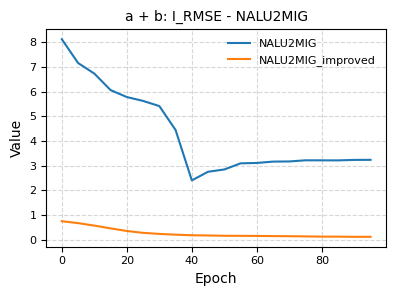

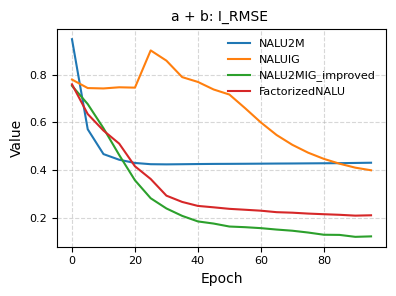

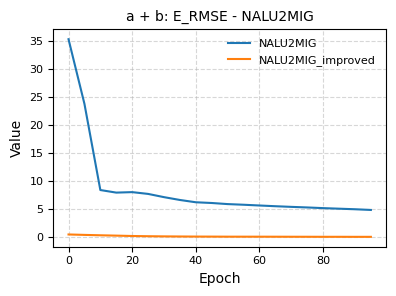

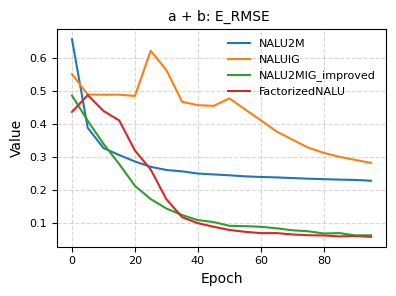

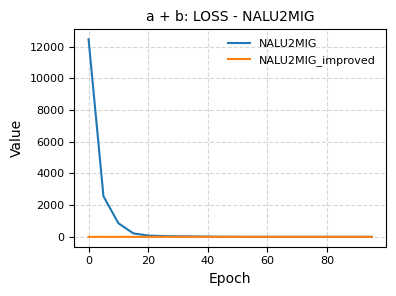

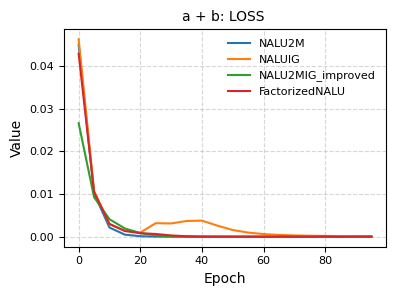

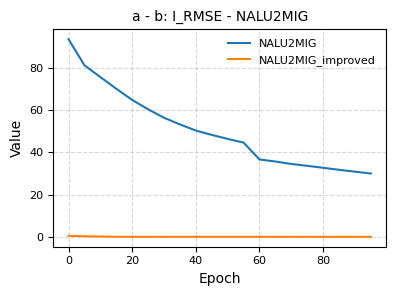

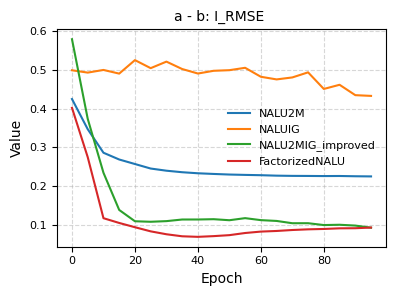

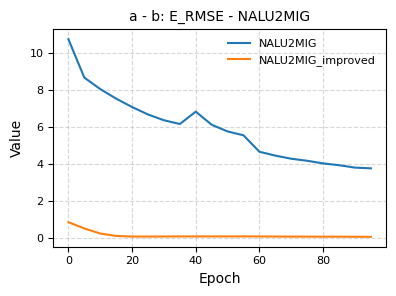

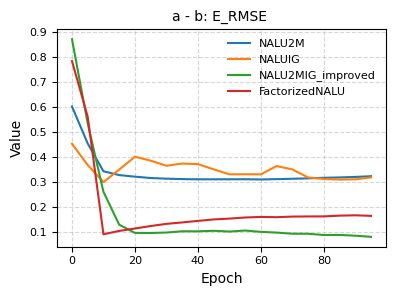

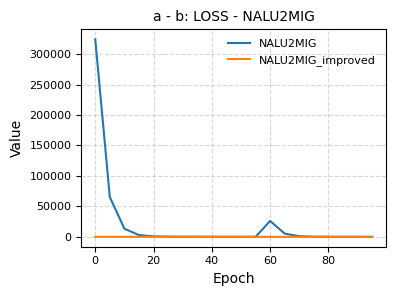

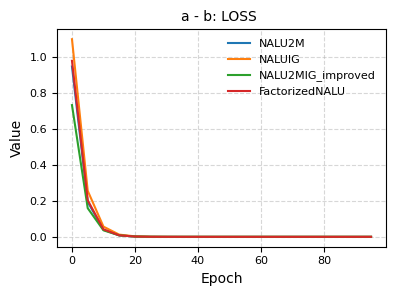

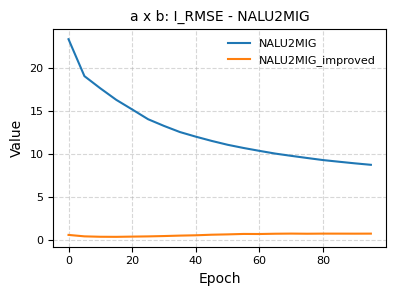

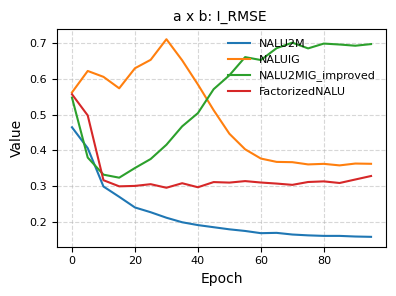

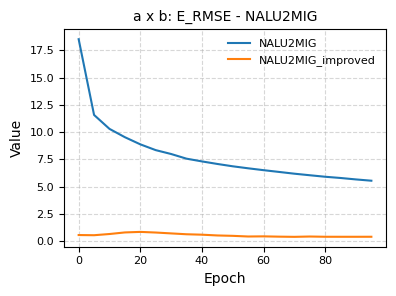

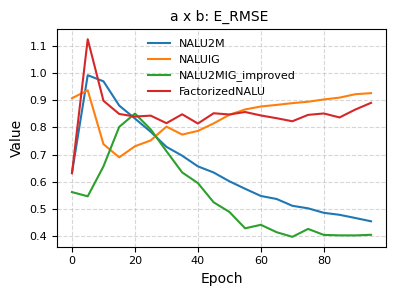

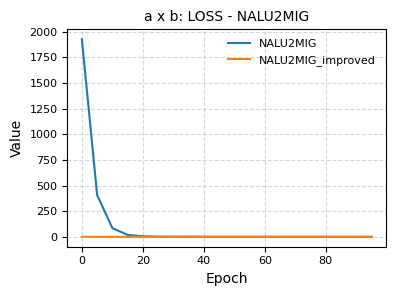

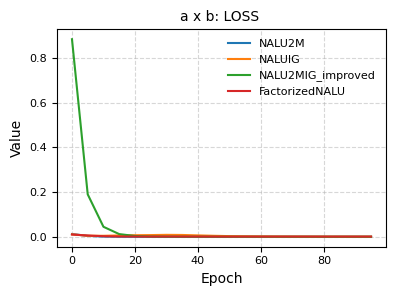

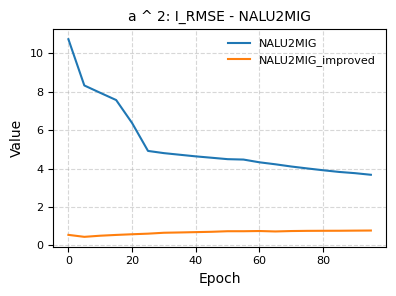

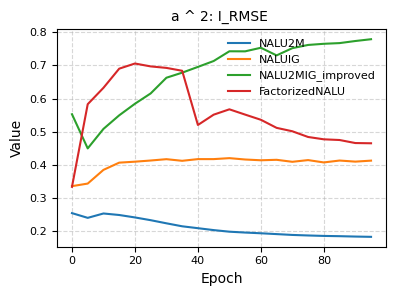

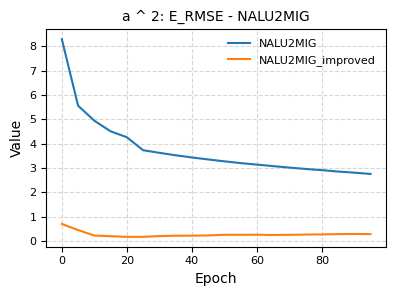

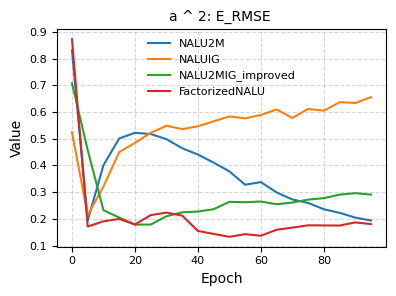

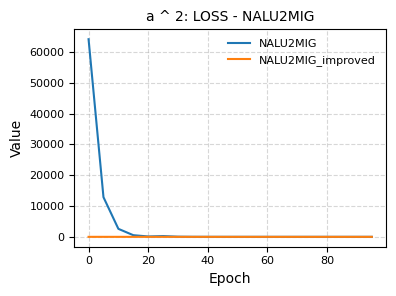

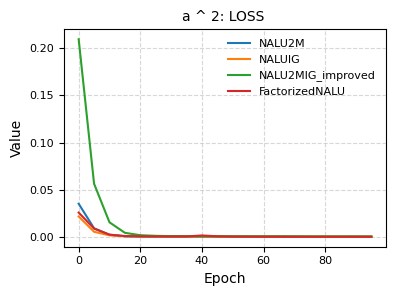

[NALU2M] Training time for a + b: 0.12087416648864746
[NALUIG] Training time for a + b: 0.1507563591003418
[NALU2MIG] Training time for a + b: 0.16463112831115723
[NALU2MIG_improved] Training time for a + b: 0.17789697647094727
[FactorizedNALU] Training time for a + b: 0.24930667877197266
[NALU2M] Training time for a - b: 0.2281327247619629
[NALUIG] Training time for a - b: 0.17730331420898438
[NALU2MIG] Training time for a - b: 0.2595686912536621
[NALU2MIG_improved] Training time for a - b: 0.25261521339416504
[FactorizedNALU] Training time for a - b: 0.2132244110107422
[NALU2M] Training time for a x b: 0.18332338333129883
[NALUIG] Training time for a x b: 0.12556004524230957
[NALU2MIG] Training time for a x b: 0.14147686958312988
[NALU2MIG_improved] Training time for a x b: 0.12714195251464844
[FactorizedNALU] Training time for a x b: 0.13113617897033691
[NALU2M] Training time for a ^ 2: 0.12367630004882812
[NALUIG] Training time for a ^ 2: 0.11520981788635254
[NALU2MIG] Training tim

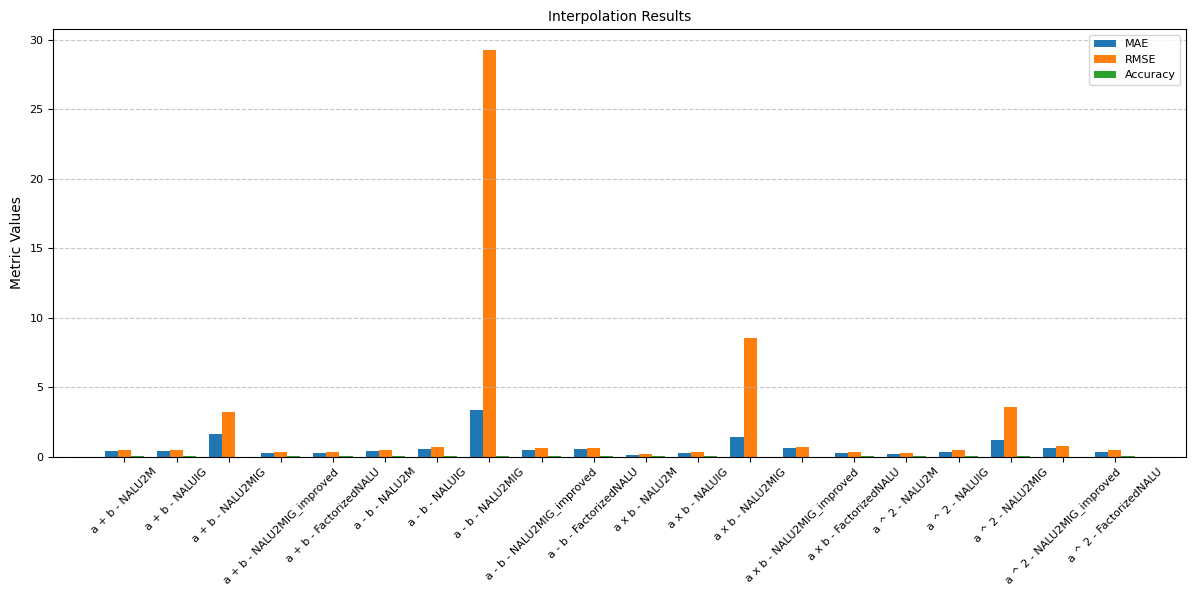

[NALU2M] Training time for a + b: 0.11441922187805176
[NALUIG] Training time for a + b: 0.14523696899414062
[NALU2MIG] Training time for a + b: 0.1655564308166504
[NALU2MIG_improved] Training time for a + b: 0.1691880226135254
[FactorizedNALU] Training time for a + b: 0.26066017150878906
[NALU2M] Training time for a - b: 0.2398064136505127
[NALUIG] Training time for a - b: 0.20490503311157227
[NALU2MIG] Training time for a - b: 0.2352006435394287
[NALU2MIG_improved] Training time for a - b: 0.24323272705078125
[FactorizedNALU] Training time for a - b: 0.21324634552001953
[NALU2M] Training time for a x b: 0.17517709732055664
[NALUIG] Training time for a x b: 0.12897562980651855
[NALU2MIG] Training time for a x b: 0.1425762176513672
[NALU2MIG_improved] Training time for a x b: 0.1280672550201416
[FactorizedNALU] Training time for a x b: 0.12694787979125977
[NALU2M] Training time for a ^ 2: 0.12443304061889648
[NALUIG] Training time for a ^ 2: 0.11921429634094238
[NALU2MIG] Training time 

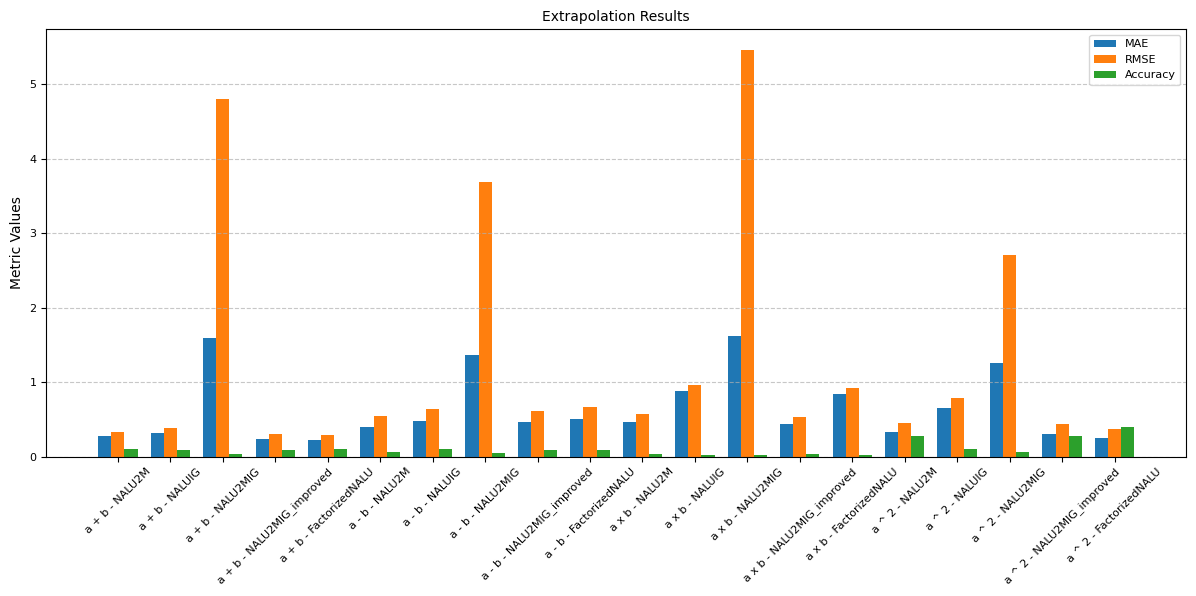

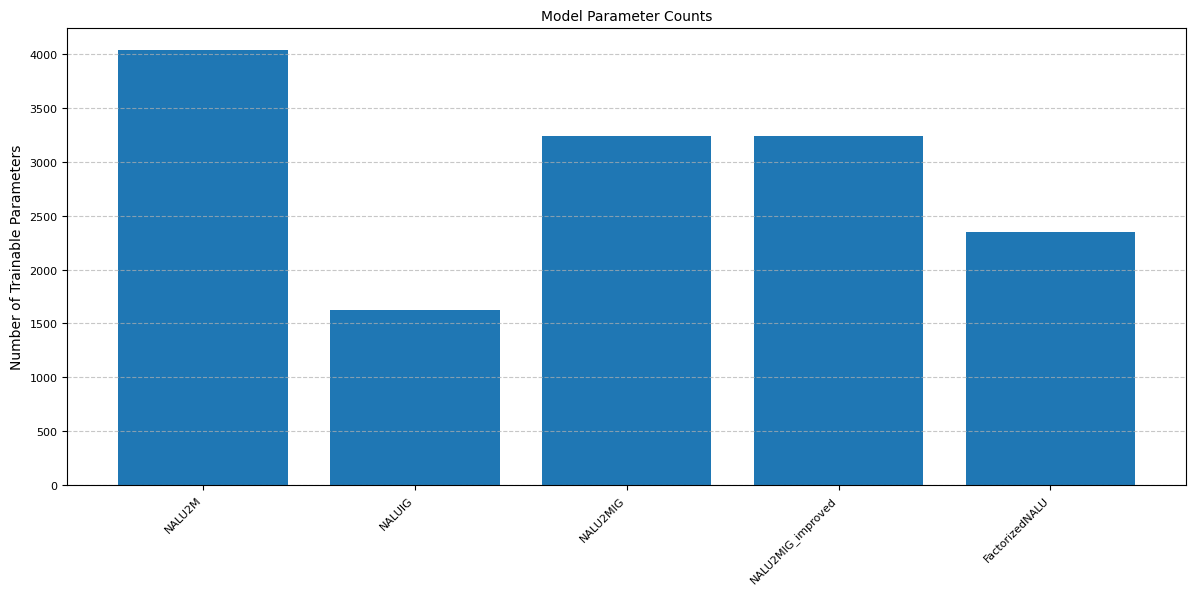

In [27]:
if __name__ == "__main__":
    run_experiment()